# Sensor timeline graphs (dual-axis progressive RMSE)

Reads the four Excel files in `data/` and plots **timeline graphs** matching the reference style:

- **X-axis:** time (`Timeline Horizon (hh:mm:ss)`)
- **Left Y-axis:** sensor + reference meter (per chat labels)
- **Right Y-axis:** progressive cumulative RMSE + overall steady-state RMSE

Run all cells (or **Shift+Enter** step by step). Figures are shown inline and saved under `figures/`.

The final section fits **OLS calibration** for all four sensors (equation, 95% CIs, accuracy) and saves `calibration_ols_summary.csv`.

In [1]:
%matplotlib inline

from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator

DATA_DIR = Path('data')
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'grid.linestyle': ':',
})

print('Data folder:', DATA_DIR.resolve())
print('Figures folder:', FIG_DIR.resolve())

Data folder: D:\StartUps\BitnBolt\hydroponics ML\new start 2\data
Figures folder: D:\StartUps\BitnBolt\hydroponics ML\new start 2\figures


In [2]:
def find_excel(glob_pattern: str) -> Path:
    matches = sorted(DATA_DIR.glob(glob_pattern))
    if not matches:
        raise FileNotFoundError(f'No file matching {glob_pattern!r} in {DATA_DIR.resolve()}')
    return matches[0]


def parse_timeline(series: pd.Series) -> pd.Series:
    """Parse Excel time column to datetime on a fixed date (for plotting only)."""
    base = pd.Timestamp('2000-01-01')
    if pd.api.types.is_datetime64_any_dtype(series):
        return series.dt.floor('s')
    parsed = pd.to_datetime(series.astype(str).str.strip(), errors='coerce')
    if parsed.notna().mean() > 0.9:
        return parsed
    return pd.to_datetime(base.strftime('%Y-%m-%d ') + series.astype(str).str.strip(), errors='coerce')


def progressive_rmse(sensor: np.ndarray, reference: np.ndarray) -> np.ndarray:
    err = sensor - reference
    n = len(err)
    return np.sqrt(np.cumsum(err ** 2) / np.arange(1, n + 1))


def load_timeline_dataset(path: Path, sheet_name=0) -> pd.DataFrame:
    df = pd.read_excel(path, sheet_name=sheet_name)
    df = df.dropna(how='all').copy()
    cols = [str(c).strip() for c in df.columns]
    df.columns = cols

    time_col = next(c for c in cols if 'time' in c.lower())
    value_cols = [c for c in cols if c != time_col]
    if len(value_cols) < 2:
        raise ValueError(f'Expected sensor + meter columns in {path.name}, got {cols}')

    sensor_col, meter_col = value_cols[0], value_cols[1]
    out = pd.DataFrame({
        'time': parse_timeline(df[time_col]),
        'sensor': pd.to_numeric(df[sensor_col], errors='coerce'),
        'meter': pd.to_numeric(df[meter_col], errors='coerce'),
    }).dropna().reset_index(drop=True)
    return out


PLOT_CONFIGS = [
    dict(
        key='tds',
        glob='*TDS*.xlsx',
        title='NFADS TDS Timeline with Dual-Axis Progressive Cumulative RMSE',
        y_label='TDS (PPM)',
        rmse_unit='PPM',
        sensor_legend='TDS Sensor Stream',
        meter_legend='TDS Meter Baseline (True)',
        outfile='timeline_tds.png',
    ),
    dict(
        key='water_temp',
        glob='*Water*Temp*.xlsx',
        title='NFADS Nutrient Temperature Timeline with Dual-Axis Progressive Cumulative RMSE',
        y_label='Nutrient Temperature (°C)',
        rmse_unit='°C',
        sensor_legend='Nutrient Temperature Sensor Stream',
        meter_legend='Temperature Meter Baseline (True)',
        outfile='timeline_water_temp.png',
    ),
    dict(
        key='ems_temp',
        glob='EMS*.xlsx',
        title='Unified EMS Climate Timeline with Dual-Axis Progressive Cumulative RMSE',
        y_label='Air Temperature (°C)',
        rmse_unit='°C',
        sensor_legend='Environment Temp Sensor Stream',
        meter_legend='Temperature Meter Baseline (True)',
        outfile='timeline_ems_temp.png',
    ),
    dict(
        key='lux',
        glob='LMS*.xlsx',
        title='LMS Light Intensity Timeline with Dual-Axis Progressive Cumulative RMSE',
        y_label='Light Intensity (Lux)',
        rmse_unit='Lux',
        sensor_legend='BH1750 Sensor Stream',
        meter_legend='TSL2591 Meter Baseline (True)',
        outfile='timeline_lux.png',
    ),
]

datasets = {}
for cfg in PLOT_CONFIGS:
    path = find_excel(cfg['glob'])
    df = load_timeline_dataset(path)
    datasets[cfg['key']] = df
    print(f"{cfg['key']:12} | {path.name:28} | n = {len(df):4} | {df['time'].iloc[0]} -> {df['time'].iloc[-1]}")

tds          | Dosing_TDS.xlsx              | n =   42 | 2026-06-03 13:10:45 -> 2026-06-03 13:17:35
water_temp   | Dosing_Water Temp (1).xlsx   | n =   62 | 2026-06-03 07:05:25 -> 2026-06-03 07:15:35
ems_temp     | EMS_temp_sensor (1).xlsx     | n =   53 | 2026-06-03 06:55:05 -> 2026-06-03 07:03:45
lux          | LMS_Lux (1).xlsx             | n =  753 | 2026-06-03 08:50:10 -> 2026-06-03 17:11:30


In [3]:
def plot_dual_axis_timeline(df: pd.DataFrame, cfg: dict, save: bool = True):
    """Reference-style dual-axis timeline: sensor, meter, progressive RMSE, steady-state RMSE."""
    t = df['time']
    sensor = df['sensor'].to_numpy()
    meter = df['meter'].to_numpy()
    prog_rmse = progressive_rmse(sensor, meter)
    steady_rmse = float(np.sqrt(np.mean((sensor - meter) ** 2)))

    fig, ax1 = plt.subplots(figsize=(13.5, 5.8))
    ax2 = ax1.twinx()

    ax1.plot(
        t, sensor,
        color='#E67E22', linewidth=1.6, marker='o', markersize=4,
        label=cfg['sensor_legend'],
    )
    ax1.plot(
        t, meter,
        color='#2471A3', linewidth=1.6, linestyle='--', marker='s', markersize=4,
        label=cfg['meter_legend'],
    )
    ax2.plot(
        t, prog_rmse,
        color='#7D3C98', linewidth=1.6, marker='v', markersize=4,
        label='Progressive Cumulative RMSE',
    )
    ax2.axhline(
        steady_rmse, color='#1E8449', linestyle=':', linewidth=2.0,
        label=f'Overall Steady-State RMSE ({steady_rmse:.4f} {cfg["rmse_unit"]})',
    )

    ax1.set_title(cfg['title'], fontsize=12, fontweight='bold', pad=12)
    ax1.set_xlabel('Timeline Horizon (hh:mm:ss)', fontsize=10)
    ax1.set_ylabel(cfg['y_label'], fontsize=10)
    ax2.set_ylabel(f'Root Mean Square Error ({cfg["rmse_unit"]})', fontsize=10, color='#7D3C98')
    ax2.tick_params(axis='y', labelcolor='#7D3C98')
    ax2.yaxis.set_major_locator(MaxNLocator(nbins=8))

    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    fig.autofmt_xdate(rotation=0, ha='center')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(
        lines1 + lines2, labels1 + labels2,
        loc='upper center', bbox_to_anchor=(0.5, -0.14),
        ncol=2, frameon=True, fancybox=True, shadow=True, fontsize=9,
    )

    for ax in (ax1, ax2):
        ax.set_axisbelow(True)
    fig.tight_layout()

    if save:
        out_path = FIG_DIR / cfg['outfile']
        fig.savefig(out_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {out_path}')

    plt.show()
    return dict(steady_rmse=steady_rmse, n=len(df))

NFADS TDS Timeline with Dual-Axis Progressive Cumulative RMSE
Saved: figures\timeline_tds.png


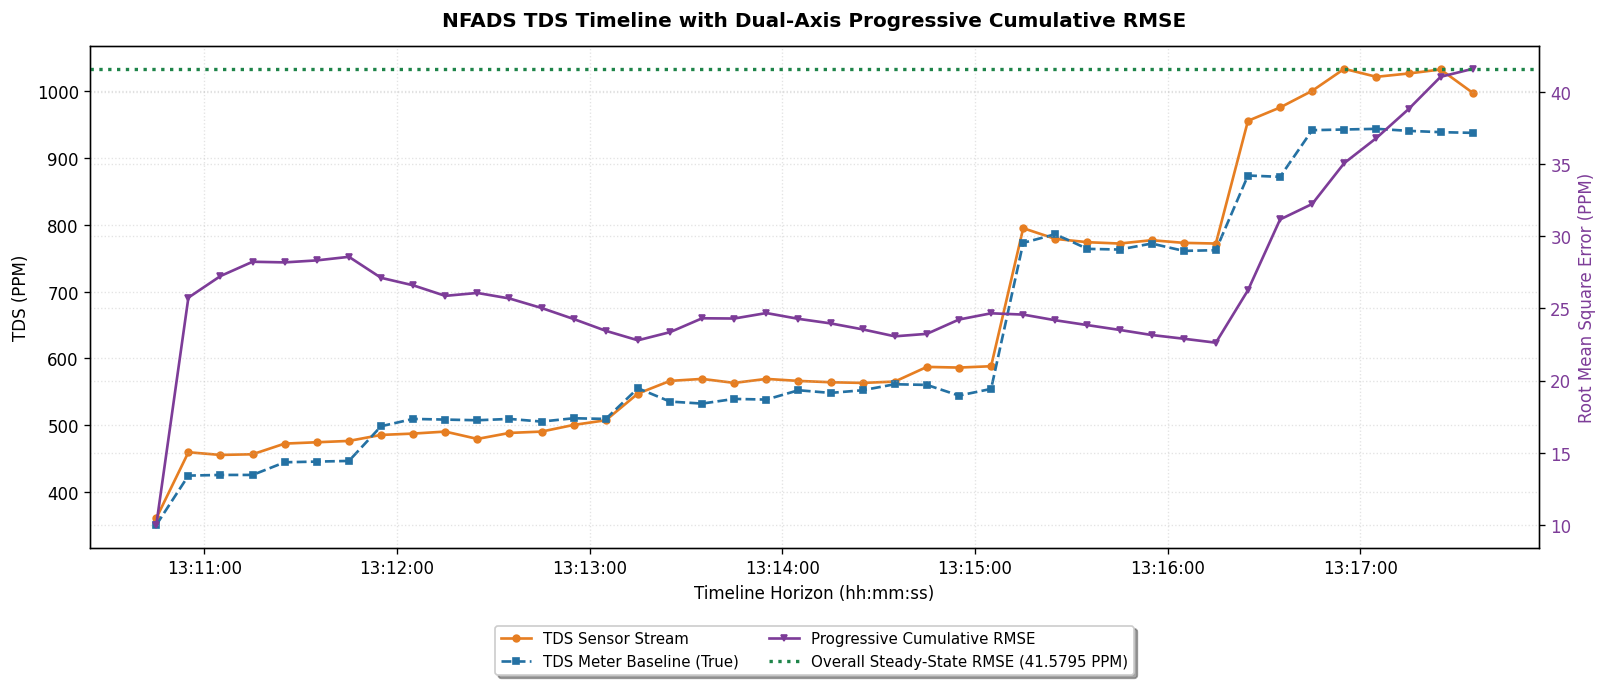

NFADS Nutrient Temperature Timeline with Dual-Axis Progressive Cumulative RMSE
Saved: figures\timeline_water_temp.png


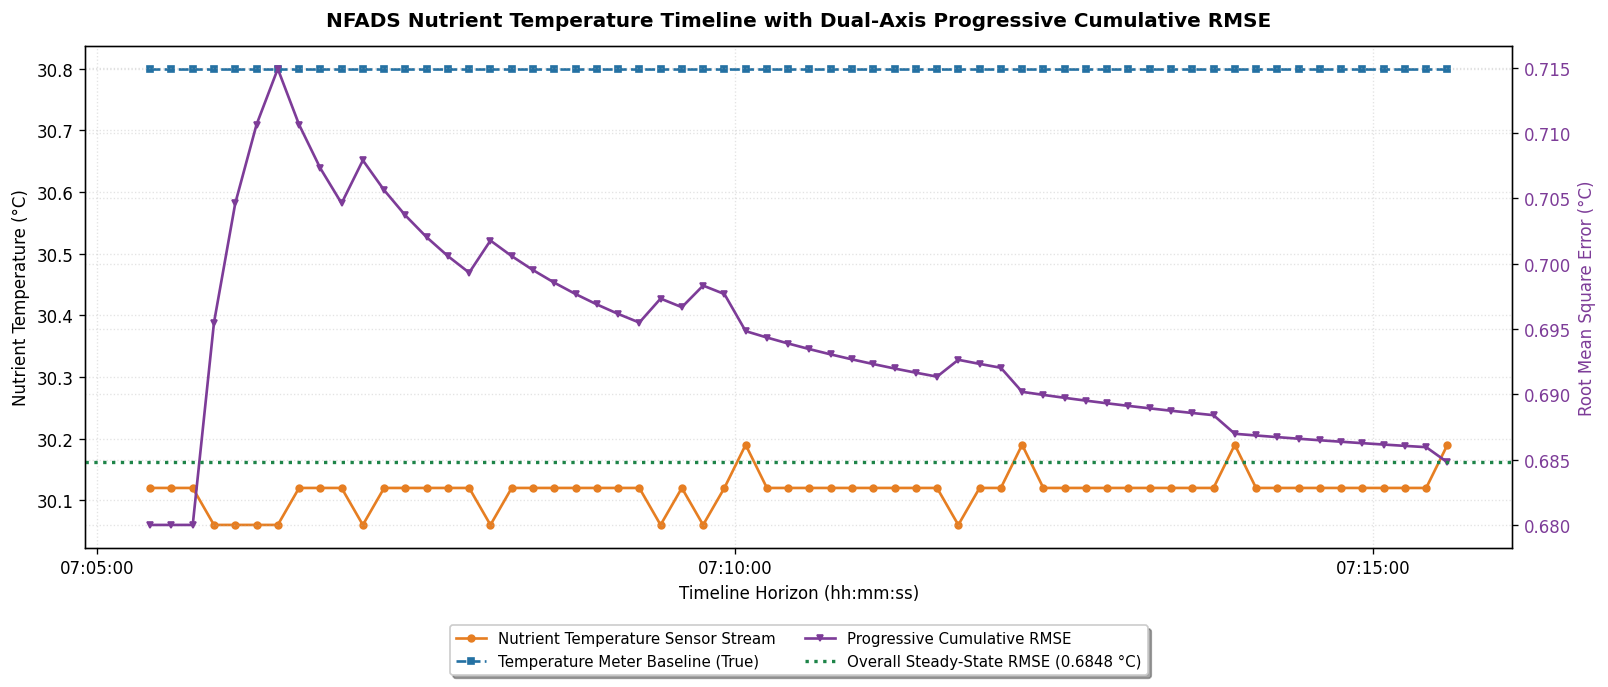

Unified EMS Climate Timeline with Dual-Axis Progressive Cumulative RMSE
Saved: figures\timeline_ems_temp.png


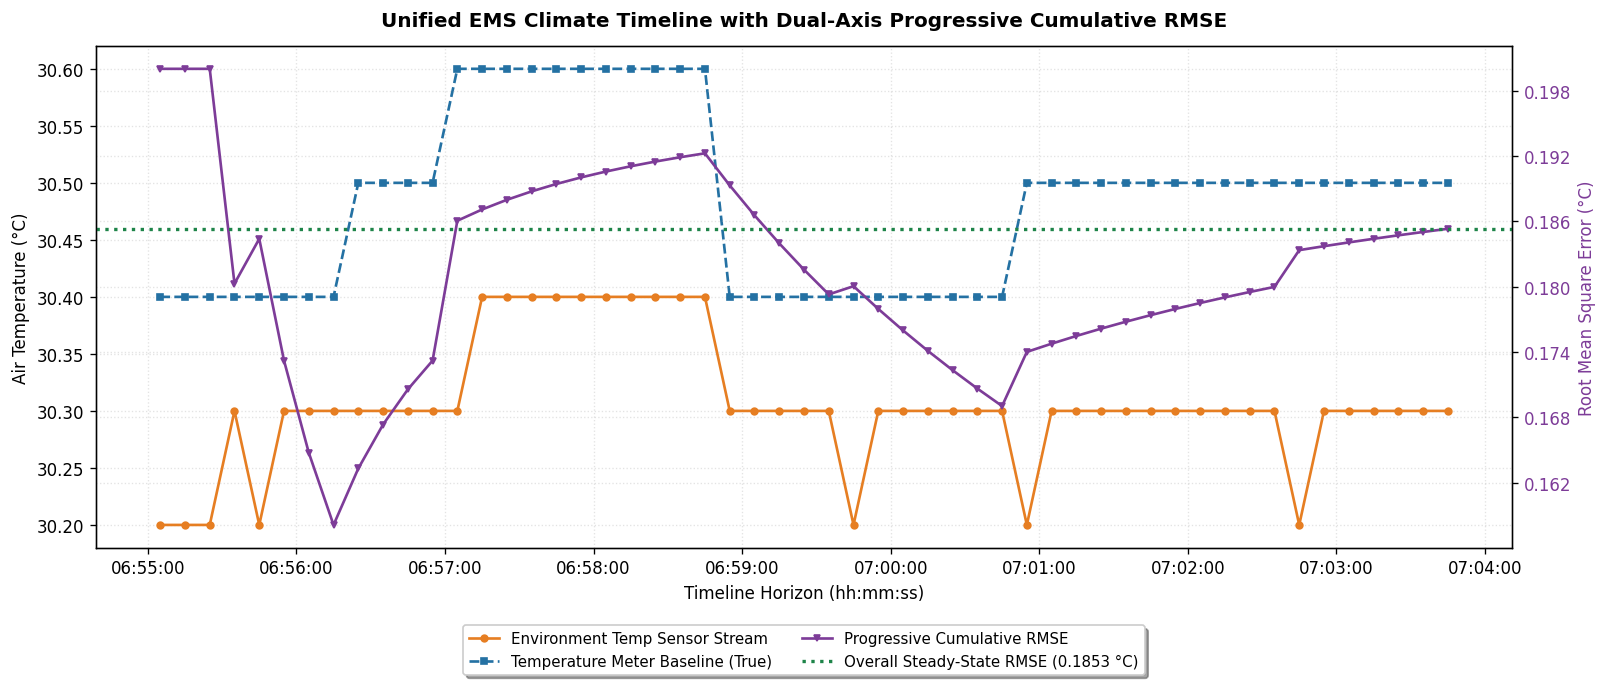

LMS Light Intensity Timeline with Dual-Axis Progressive Cumulative RMSE
Saved: figures\timeline_lux.png


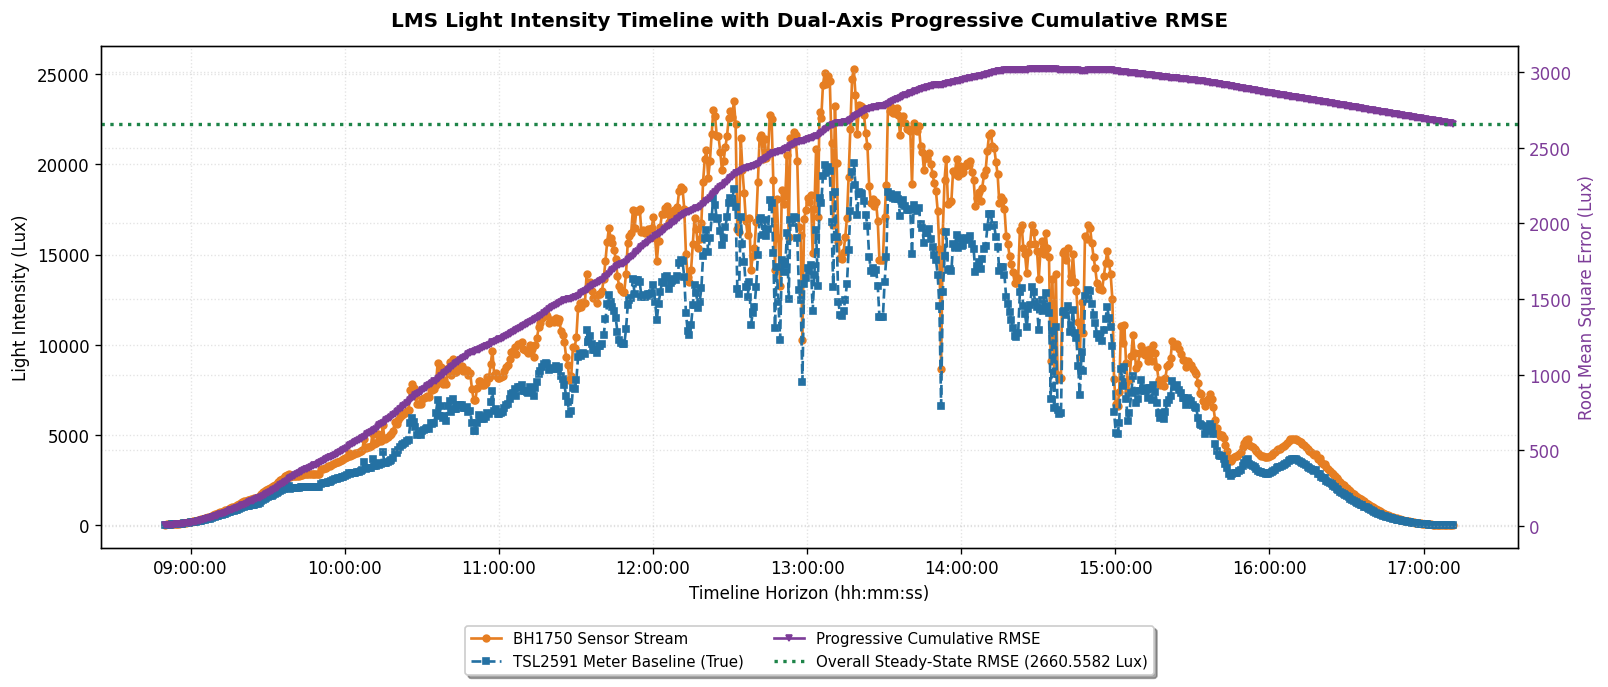

,dataset,y_axis,n_points,steady_state_rmse,rmse_unit
0,tds,TDS (PPM),42,41.579528,PPM
1,water_temp,Nutrient Temperature (°C),62,0.684793,°C
2,ems_temp,Air Temperature (°C),53,0.185310,°C
3,lux,Light Intensity (Lux),753,2660.558224,Lux


In [4]:
summary_rows = []
for cfg in PLOT_CONFIGS:
    print('=' * 72)
    print(cfg['title'])
    stats = plot_dual_axis_timeline(datasets[cfg['key']], cfg)
    summary_rows.append({
        'dataset': cfg['key'],
        'y_axis': cfg['y_label'],
        'n_points': stats['n'],
        'steady_state_rmse': stats['steady_rmse'],
        'rmse_unit': cfg['rmse_unit'],
    })

summary = pd.DataFrame(summary_rows)
try:
    from IPython.display import display
    display(summary)
except ImportError:
    print(summary.to_string(index=False))

---
## OLS calibration & accuracy (all 4 sensors)

**Ordinary Least Squares (OLS)** fits a linear calibration from raw sensor readings to the reference meter:

$$\text{Estimated value} = \text{slope} \times (\text{Raw Sensor Reading}) + \text{intercept}$$

For each sensor we report:
- **Calibration equation** (slope, intercept)
- **95% calibration intervals** for slope and intercept (`estimate ± margin`)
- **Accuracy** after calibration: RMSE, MAE, bias, R² (vs reference meter)
- **Raw accuracy** (uncalibrated sensor vs meter) for comparison

In [5]:
from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

CALIBRATION_LABELS = {
    'tds': 'Estimated TDS',
    'water_temp': 'Estimated Fluid Temperature',
    'ems_temp': 'Estimated Air Temperature',
    'lux': 'Estimated Light Intensity',
}


def ols_calibration(sensor: np.ndarray, reference: np.ndarray) -> dict:
    """OLS: reference = slope * sensor + intercept (same form as calibration image)."""
    x = np.asarray(sensor, dtype=float)
    y = np.asarray(reference, dtype=float)
    n = len(x)
    slope, intercept, r, p, se_slope = stats.linregress(x, y)

    dof = max(n - 2, 1)
    t_crit = stats.t.ppf(0.975, dof)
    slope_ci = (slope - t_crit * se_slope, slope + t_crit * se_slope)

    se_intercept = se_slope * np.sqrt(np.sum(x ** 2) / n)
    intercept_ci = (intercept - t_crit * se_intercept, intercept + t_crit * se_intercept)

    y_cal = slope * x + intercept

    def accuracy_metrics(pred, true):
        err = pred - true
        return dict(
            RMSE=float(np.sqrt(mean_squared_error(true, pred))),
            MAE=float(mean_absolute_error(true, pred)),
            Bias=float(np.mean(err)),
            R2=float(r2_score(true, pred)),
        )

    raw_acc = accuracy_metrics(x, y)
    cal_acc = accuracy_metrics(y_cal, y)

    slope_pm = (slope_ci[1] - slope_ci[0]) / 2
    intercept_pm = (intercept_ci[1] - intercept_ci[0]) / 2

    return dict(
        n=n,
        slope=slope,
        intercept=intercept,
        slope_ci_lo=slope_ci[0],
        slope_ci_hi=slope_ci[1],
        slope_pm=slope_pm,
        intercept_ci_lo=intercept_ci[0],
        intercept_ci_hi=intercept_ci[1],
        intercept_pm=intercept_pm,
        pearson_r=r,
        p_value=p,
        raw=raw_acc,
        calibrated=cal_acc,
        y_calibrated=y_cal,
    )


def format_pm(value: float, margin: float, decimals: int = 4) -> str:
    """Estimate with symmetric 95% calibration interval (± half-width of CI)."""
    return f'{value:.{decimals}f} ± {margin:.{decimals}f}'


def format_equation(label: str, unit: str, slope: float, intercept: float) -> str:
    sign = '+' if intercept >= 0 else '-'
    return (
        f'{label} ({unit}) = {slope:.4f} x (Raw Sensor Reading) '
        f'{sign} {abs(intercept):.4f}'
    )


def format_equation_with_interval(
    label: str, unit: str, slope: float, intercept: float,
    slope_pm: float, intercept_pm: float,
) -> str:
    sign = '+' if intercept >= 0 else '-'
    return (
        f'{label} ({unit}) = ({format_pm(slope, slope_pm)}) x (Raw Sensor Reading) '
        f'{sign} ({format_pm(abs(intercept), intercept_pm)})'
    )


calibration_rows = []
print('=' * 80)
print('OLS CALIBRATION & ACCURACY — ALL SENSORS')
print('=' * 80)

for cfg in PLOT_CONFIGS:
    df = datasets[cfg['key']]
    sensor = df['sensor'].to_numpy()
    meter = df['meter'].to_numpy()
    ols = ols_calibration(sensor, meter)

    label = CALIBRATION_LABELS[cfg['key']]
    unit = cfg['rmse_unit']
    eq = format_equation(label, unit, ols['slope'], ols['intercept'])
    eq_interval = format_equation_with_interval(
        label, unit, ols['slope'], ols['intercept'],
        ols['slope_pm'], ols['intercept_pm'],
    )

    print()
    print(f"--- {cfg['key'].upper()} | {cfg['y_label']} | n = {ols['n']} ---")
    print('  Calibration equation:')
    print(f'    {eq}')
    print('  Calibration intervals (95%):')
    print(f"    Slope:     {format_pm(ols['slope'], ols['slope_pm'])}")
    print(f"    Intercept: {format_pm(ols['intercept'], ols['intercept_pm'])}")
    print('  Equation with intervals:')
    print(f'    {eq_interval}')
    print(
        f"    (range: slope [{ols['slope_ci_lo']:.4f}, {ols['slope_ci_hi']:.4f}], "
        f"intercept [{ols['intercept_ci_lo']:.4f}, {ols['intercept_ci_hi']:.4f}])"
    )
    print(f"  Pearson r = {ols['pearson_r']:.4f}  (p = {ols['p_value']:.2e})")
    print('  Accuracy (raw sensor vs meter):')
    print(
        f"    RMSE = {ols['raw']['RMSE']:.4f} {unit}  |  MAE = {ols['raw']['MAE']:.4f}  |  "
        f"Bias = {ols['raw']['Bias']:.4f}  |  R2 = {ols['raw']['R2']:.4f}"
    )
    print('  Accuracy (after OLS calibration vs meter):')
    print(
        f"    RMSE = {ols['calibrated']['RMSE']:.4f} {unit}  |  MAE = {ols['calibrated']['MAE']:.4f}  |  "
        f"Bias = {ols['calibrated']['Bias']:.4f}  |  R2 = {ols['calibrated']['R2']:.4f}"
    )

    calibration_rows.append({
        'sensor': cfg['key'],
        'quantity': cfg['y_label'],
        'n': ols['n'],
        'equation': eq,
        'equation_with_intervals': eq_interval,
        'slope': ols['slope'],
        'slope_95ci_pm': ols['slope_pm'],
        'slope_interval': format_pm(ols['slope'], ols['slope_pm']),
        'slope_95ci_lo': ols['slope_ci_lo'],
        'slope_95ci_hi': ols['slope_ci_hi'],
        'intercept': ols['intercept'],
        'intercept_95ci_pm': ols['intercept_pm'],
        'intercept_interval': format_pm(ols['intercept'], ols['intercept_pm']),
        'intercept_95ci_lo': ols['intercept_ci_lo'],
        'intercept_95ci_hi': ols['intercept_ci_hi'],
        'pearson_r': ols['pearson_r'],
        'p_value': ols['p_value'],
        'raw_RMSE': ols['raw']['RMSE'],
        'raw_MAE': ols['raw']['MAE'],
        'raw_Bias': ols['raw']['Bias'],
        'raw_R2': ols['raw']['R2'],
        'calibrated_RMSE': ols['calibrated']['RMSE'],
        'calibrated_MAE': ols['calibrated']['MAE'],
        'calibrated_Bias': ols['calibrated']['Bias'],
        'calibrated_R2': ols['calibrated']['R2'],
        'unit': unit,
    })

calibration_summary = pd.DataFrame(calibration_rows)
out_csv = Path('calibration_ols_summary.csv')
calibration_summary.to_csv(out_csv, index=False)
print()
print(f'Saved summary table: {out_csv.resolve()}')

try:
    from IPython.display import display
    display(calibration_summary)
except ImportError:
    print(calibration_summary.to_string(index=False))

OLS CALIBRATION & ACCURACY — ALL SENSORS

--- TDS | TDS (PPM) | n = 42 ---
  Calibration equation:
    Estimated TDS (PPM) = 0.8810 x (Raw Sensor Reading) + 52.8537
  Calibration intervals (95%):
    Slope:     0.8810 ± 0.0368
    Intercept: 52.8537 ± 25.1217
  Equation with intervals:
    Estimated TDS (PPM) = (0.8810 ± 0.0368) x (Raw Sensor Reading) + (52.8537 ± 25.1217)
    (range: slope [0.8442, 0.9177], intercept [27.7321, 77.9754])
  Pearson r = 0.9916  (p = 4.03e-37)
  Accuracy (raw sensor vs meter):
    RMSE = 41.5795 PPM  |  MAE = 31.6667  |  Bias = 24.8095  |  R2 = 0.9460
  Accuracy (after OLS calibration vs meter):
    RMSE = 23.1968 PPM  |  MAE = 20.8594  |  Bias = -0.0000  |  R2 = 0.9832

--- WATER_TEMP | Nutrient Temperature (°C) | n = 62 ---
  Calibration equation:
    Estimated Fluid Temperature (°C) = 0.0000 x (Raw Sensor Reading) + 30.8000
  Calibration intervals (95%):
    Slope:     0.0000 ± 0.0000
    Intercept: 30.8000 ± 0.0000
  Equation with intervals:
    Estim

,sensor,quantity,n,equation,equation_with_intervals,slope,slope_95ci_pm,slope_interval,slope_95ci_lo,slope_95ci_hi,...,p_value,raw_RMSE,raw_MAE,raw_Bias,raw_R2,calibrated_RMSE,calibrated_MAE,calibrated_Bias,calibrated_R2,unit
0,tds,TDS (PPM),42,Estimated TDS (PPM) = 0.8810 x (Raw Sensor Rea...,Estimated TDS (PPM) = (0.8810 ± 0.0368) x (Raw...,8.809541e-01,3.679306e-02,0.8810 ± 0.0368,8.441610e-01,9.177472e-01,...,4.027084e-37,41.579528,31.666667,24.809524,9.460406e-01,2.319681e+01,2.085942e+01,-5.549000e-14,0.983206,PPM
1,water_temp,Nutrient Temperature (°C),62,Estimated Fluid Temperature (°C) = 0.0000 x (R...,Estimated Fluid Temperature (°C) = (0.0000 ± 0...,2.826343e-26,3.201658e-14,0.0000 ± 0.0000,-3.201658e-14,3.201658e-14,...,1.000000e+00,0.684793,0.684194,-0.684194,-3.715341e+28,3.552714e-15,3.552714e-15,-3.552714e-15,0.000000,°C
2,ems_temp,Air Temperature (°C),53,Estimated Air Temperature (°C) = 0.9215 x (Raw...,Estimated Air Temperature (°C) = (0.9215 ± 0.2...,9.215247e-01,2.669752e-01,0.9215 ± 0.2670,6.545494e-01,1.188500e+00,...,7.030695e-09,0.185310,0.177358,-0.177358,-5.175416e+00,5.351666e-02,4.403926e-02,2.681293e-15,0.484951,°C
3,lux,Light Intensity (Lux),753,Estimated Light Intensity (Lux) = 0.7947 x (Ra...,Estimated Light Intensity (Lux) = (0.7947 ± 0....,7.946622e-01,1.192948e-03,0.7947 ± 0.0012,7.934693e-01,7.958552e-01,...,0.000000e+00,2660.558224,2207.984064,2207.981408,7.841840e-01,1.199902e+02,1.010202e+02,-6.425646e-13,0.999561,Lux
